# Day 1: The Core Workflow & Linear Models

### 1. 🚀 Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### 2. 🧠 Core Concept: The ML Workflow

**Task:** Load your dataset (e.g., `pd.read_csv(...)`).

In [2]:
df = pd.read_csv(r"datasets/House Price Prediction Dataset.csv")
df.head()

,Area_sqft,Bedrooms,Bathrooms,Stories,YearBuilt,Condition,Parking,Price_USD
0,2100,4,2.5,2,2005,Good,2,450000
1,1400,3,1.5,1,1980,Fair,1,220000
2,3100,5,3.5,3,2010,Excellent,3,650000
3,1750,3,2.0,2,1995,Good,2,320000
4,4500,6,4.5,3,2008,Excellent,3,890000


**Task:** Identify X (features) and y (target). Separate your data into `X` and `y`.

In [3]:
X = pd.DataFrame(df[['Area_sqft']]) # Keeping things simple
y = pd.DataFrame(df['Price_USD'])

**Task:** Split `X` and `y` into `X_train`, `X_test`, `y_train`, `y_test` using `train_test_split`. Set `test_size=0.2` and `random_state=42`.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Task:** Feature Scaling. We do this for all linear models.
1. Create an instance of `StandardScaler` called `scaler`.
2. Fit the scaler *only* on the training data: `scaler.fit(X_train)`.
3. Transform both sets: `X_train_scaled = scaler.transform(X_train)` and `X_test_scaled = scaler.transform(X_test)`.

In [5]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

### 3. 📈 Part A: Linear Models for Regression (Predicting a Number)

**Task:** Use a regression dataset (e.g., California Housing, Boston Housing, or a custom one with a numerical target).

**Task:** Import the models and metrics.
```python
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
```

In [6]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
#To store model performances
model_stat = {
    'Model Name' : [],
    'RMSE' : [],
    'R^2' : []
}

#### Model 1: `LinearRegression` (The Baseline)

**Task:** 
1. Create an instance: `model_lr = LinearRegression()`
2. Train the model: `model_lr.fit(X_train_scaled, y_train)`
3. Make predictions: `y_pred_lr = model_lr.predict(X_test_scaled)`
4. Evaluate:
    - Calculate and print the **Root Mean Squared Error (RMSE)**: `np.sqrt(mean_squared_error(y_test, y_pred_lr))`
    - Calculate and print the **R-squared (R²)**: `r2_score(y_test, y_pred_lr)`
    - Inspect coefficients: `model_lr.coef_`

In [8]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled,y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2 = r2_score(y_test,y_pred_lr)
print(f"Coef : {model_lr.coef_}")
model_stat['Model Name'].append("Linear Regression")
model_stat['RMSE'].append(rmse)
model_stat['R^2'].append(r2)

Coef : [[224165.91564606]]


#### Model 2: `Ridge` (L2 Regularization)

**Task:** 
1. Create an instance: `model_ridge = Ridge(alpha=1.0)`
2. Train and predict.
3. Evaluate: Calculate and print RMSE and R². Compare them to `LinearRegression`.

In [9]:
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled,y_train)
y_pred_lr = model_ridge.predict(X_test_scaled)

In [10]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2 = r2_score(y_test,y_pred_lr)

model_stat['Model Name'].append("Ridge")
model_stat['RMSE'].append(rmse)
model_stat['R^2'].append(r2)

#### Model 3: `Lasso` (L1 Regularization)

**Task:** 
1. Create an instance: `model_lasso = Lasso(alpha=0.1)`
2. Train and predict.
3. Evaluate: Calculate and print RMSE and R².
4. Inspect coefficients: `model_lasso.coef_`. (Note which ones are now zero).

In [11]:
model_lasso = Lasso(alpha=0.1)
model_lasso.fit(X_train_scaled,y_train)
y_pred_lr = model_lasso.predict(X_test_scaled)

In [12]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2 = r2_score(y_test,y_pred_lr)
print(f"Coef : {model_lasso.coef_}")
model_stat['Model Name'].append("Lasso")
model_stat['RMSE'].append(rmse)
model_stat['R^2'].append(r2)

Coef : [224165.81564606]


#### Model 4: `ElasticNet`

**Task:** 
1. Create an instance: `model_enet = ElasticNet(alpha=0.1, l1_ratio=0.5)`
2. Train, predict, and evaluate (RMSE, R²).

In [13]:
model_El = ElasticNet(alpha=0.1, l1_ratio=0.5)
model_El.fit(X_train_scaled,y_train)
y_pred_lr = model_El.predict(X_test_scaled)

In [14]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2 = r2_score(y_test,y_pred_lr)

model_stat['Model Name'].append("ElasticNet")
model_stat['RMSE'].append(rmse)
model_stat['R^2'].append(r2)

#### Model 5: `SGDRegressor`

**Task:** 
1. Create an instance: `model_sgd = SGDRegressor(max_iter=1000, tol=1e-3)`
2. Train, predict, and evaluate (RMSE, R²).

In [15]:
model_SGD = SGDRegressor(max_iter=2000, tol=1e-3)
model_SGD.fit(X_train_scaled,y_train)
y_pred_lr = model_SGD.predict(X_test_scaled)

In [16]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2 = r2_score(y_test,y_pred_lr)

model_stat['Model Name'].append("SGDRegressor")
model_stat['RMSE'].append(rmse)
model_stat['R^2'].append(r2)

## Model Performance Table

In [17]:
model_stat_df = pd.DataFrame(model_stat)
model_stat_df

,Model Name,RMSE,R^2
0,Linear Regression,8442.320563,0.999058
1,Ridge,34133.869887,0.984593
2,Lasso,8442.352736,0.999058
3,ElasticNet,17473.427544,0.995963
4,SGDRegressor,8441.852566,0.999058


## Model Prediction Graph

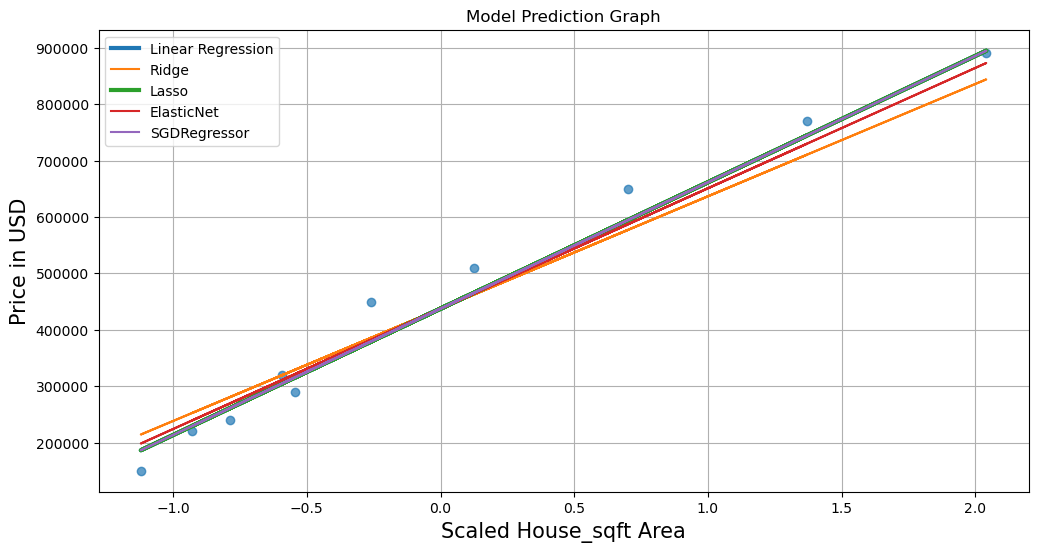

In [18]:
X = scaler.fit_transform(X)
fig, ax = plt.subplots(figsize = (12,6))
ax.scatter(X,y,alpha=0.7)

ax.plot(X,model_lr.predict(X), label = "Linear Regression",linewidth = 3)
ax.plot(X,model_ridge.predict(X), label = "Ridge")
ax.plot(X,model_lasso.predict(X), label = "Lasso",linewidth = 3)
ax.plot(X,model_El.predict(X), label = "ElasticNet")
ax.plot(X,model_SGD.predict(X), label = "SGDRegressor")

ax.set_xlabel("Scaled House_sqft Area",size = 15)
ax.set_ylabel("Price in USD",size = 15)
ax.set_title("Model Prediction Graph")
ax.legend()
ax.grid()
plt.show()

---

### 4. 📊 Part B: Linear Models for Classification (Predicting a Category)

**Task:** Use a classification dataset (e.g., Breast Cancer, Titanic, or a custom one with a categorical target). You may need to reload data and re-do the workflow steps (split, scale).

In [19]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Task:** Import the models and metrics.
```python
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
```

In [20]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Model 1: `LogisticRegression` (The Baseline)

**Task:** 
1. Create an instance: `model_logreg = LogisticRegression()`
2. Train the model: `model_logreg.fit(X_train_scaled, y_train)`
3. Make predictions: `y_pred_logreg = model_logreg.predict(X_test_scaled)`
4. Evaluate:
    - Calculate and print **Accuracy**: `accuracy_score(y_test, y_pred_logreg)`
    - Print the **Confusion Matrix**: `confusion_matrix(y_test, y_pred_logreg)`
    - Print the full **Classification Report**: `classification_report(y_test, y_pred_logreg)`

Accuracy :  1.0
Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



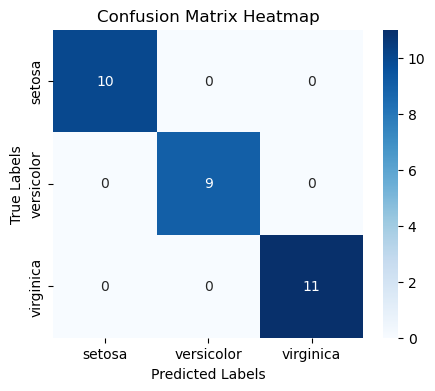

In [21]:
model_logred = LogisticRegression()
model_logred.fit(X_train_scaled, y_train)
y_pred_logred = model_logred.predict(X_test_scaled)

print("Accuracy : ",accuracy_score(y_test,y_pred_logred))
print("Classification Report\n",classification_report(y_test,y_pred_logred))
conf_matrix = confusion_matrix(y_test, y_pred_logred)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

#### Model 2: `SGDClassifier`

**Task:** 
1. Create an instance: `model_sgd_clf = SGDClassifier(loss='log_loss', max_iter=1000)`
2. Train, predict, and evaluate (Accuracy, Confusion Matrix, Classification Report).

Accuracy :  1.0
Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



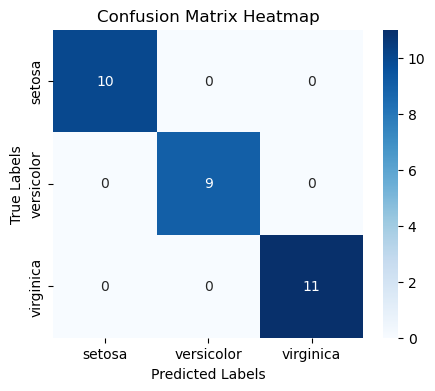

In [22]:
model_sgd_clf = SGDClassifier(loss='log_loss', max_iter=2000)
model_sgd_clf.fit(X_train_scaled, y_train)
y_pred_sgd_clf = model_sgd_clf.predict(X_test_scaled)

print("Accuracy : ",accuracy_score(y_test,y_pred_sgd_clf))
print("Classification Report\n",classification_report(y_test,y_pred_sgd_clf))
conf_matrix = confusion_matrix(y_test, y_pred_sgd_clf)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()